In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

In [2]:
import pandas as pd
import joblib
from src.calibration import *
from src.io_utils import *

In [3]:
# load model
pipeline = load_model("../models/financial_health_xgboost_pipeline.pkl")

# load dataset
PATH = "../data/"
train_df = pd.read_csv(PATH + "train_msmes_data.csv")
test_df = pd.read_csv(PATH + "test_msmes_data.csv")

X_train = train_df.drop(columns = ["Default"])
y_train = train_df["Default"]

X_test = test_df.drop(columns = ["Default"])
y_test = test_df["Default"]

In [4]:
# Fit calibration
calibrated_model = fit_probability_calibration(pipeline, X_train, y_train, method="isotonic", cv=5)

# save calibrated model
save_model(calibrated_model, "../models/calibrated_model.pkl")

In [5]:
# Evaluate model
metrics = evaluate_calibration(
    pipeline,
    calibrated_model,
    X_test,
    y_test,
)

metrics

{'raw_brier_score': 0.06733978539705276,
 'calibrated_brier_score': 0.042868500818450374,
 'raw_log_loss': 0.21191540360450745,
 'calibrated_log_loss': 0.14131998781037713}

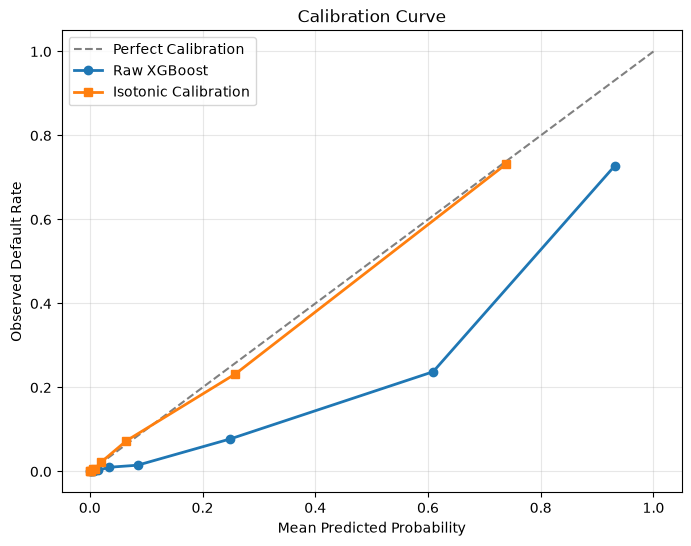

In [6]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

# Predicted probabilities
raw_prob = pipeline.predict_proba(X_test)[:, 1]
calibrated_prob = calibrated_model.predict_proba(X_test)[:, 1]

# Compute calibration curves
raw_true, raw_pred = calibration_curve(
    y_test,
    raw_prob,
    n_bins=10,
    strategy="quantile"
)

cal_true, cal_pred = calibration_curve(
    y_test,
    calibrated_prob,
    n_bins=10,
    strategy="quantile"
)

# Plot
plt.figure(figsize=(8, 6))

# Perfect calibration
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Perfect Calibration"
)

# Raw model
plt.plot(
    raw_pred,
    raw_true,
    marker="o",
    linewidth=2,
    label="Raw XGBoost"
)

# Calibrated model
plt.plot(
    cal_pred,
    cal_true,
    marker="s",
    linewidth=2,
    label="Isotonic Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Default Rate")
plt.title("Calibration Curve")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

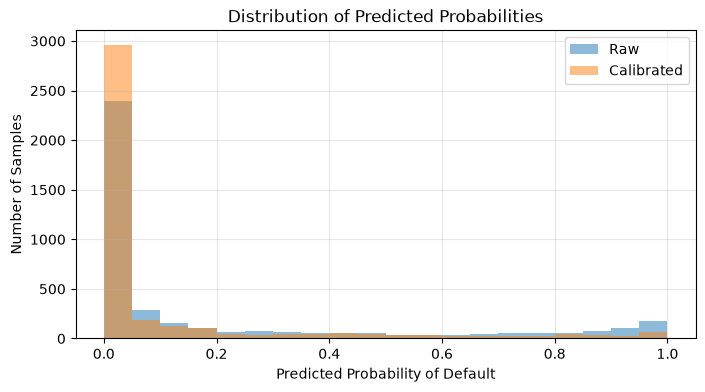

In [7]:
plt.figure(figsize=(8, 4))

plt.hist(
    raw_prob,
    bins=20,
    alpha=0.5,
    label="Raw",
)

plt.hist(
    calibrated_prob,
    bins=20,
    alpha=0.5,
    label="Calibrated",
)

plt.xlabel("Predicted Probability of Default")
plt.ylabel("Number of Samples")
plt.title("Distribution of Predicted Probabilities")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [8]:
X_test.columns

Index(['Business_Size', 'Business_Age', 'Industry_Type', 'Entity_Type',
       'Monthly_GST_Sales', 'GST_Growth_Rate', 'GST_Filing_Delay',
       'GST_Compliance_Rate', 'Monthly_UPI_Count', 'Monthly_UPI_Value',
       'Digital_Sales_Ratio', 'Average_Bank_Balance', 'Monthly_Credit',
       'Monthly_Debit', 'Cashflow_Volatility', 'Employee_Count',
       'Payroll_Consistency', 'Vendor_Payment_Delay', 'Working_Capital_Cycle',
       'EMI_Bounce_Count'],
      dtype='str')